# ⚠️ **Warning**

Installing R packages in Colab is a hassle...  
You can either run this notebook on a local machine or follow along.

Running this notebook on Colab will (unfortunately) not work.

In [1]:
# Install if needed:
install.packages(c("xgboost", "fastshap", "iml", "sensitivity"))

Installation des packages dans 'C:/Users/ilidr/AppData/Local/R/win-library/4.5'
(car 'lib' n'est pas spécifié)



le package 'xgboost' a été décompressé et les sommes MD5 ont été vérifiées avec succés
le package 'fastshap' a été décompressé et les sommes MD5 ont été vérifiées avec succés
le package 'iml' a été décompressé et les sommes MD5 ont été vérifiées avec succés
le package 'sensitivity' a été décompressé et les sommes MD5 ont été vérifiées avec succés

Les packages binaires téléchargés sont dans
	C:\Users\ilidr\AppData\Local\Temp\RtmpAFStmW\downloaded_packages


In [2]:
suppressPackageStartupMessages({
    library(tidyverse)
    library(xgboost)
    library(fastshap)
    library(iml)
    library(sensitivity)
    library(parallel)
})

Warning message:
"le package 'tidyverse' a été compilé avec la version R 4.5.3"
Warning message:
"le package 'ggplot2' a été compilé avec la version R 4.5.2"
Warning message:
"le package 'tibble' a été compilé avec la version R 4.5.1"
Warning message:
"le package 'tidyr' a été compilé avec la version R 4.5.1"
Warning message:
"le package 'readr' a été compilé avec la version R 4.5.1"
Warning message:
"le package 'purrr' a été compilé avec la version R 4.5.2"
Warning message:
"le package 'forcats' a été compilé avec la version R 4.5.1"
Warning message:
"le package 'lubridate' a été compilé avec la version R 4.5.1"
Warning message:
"le package 'xgboost' a été compilé avec la version R 4.5.3"
Warning message:
"le package 'fastshap' a été compilé avec la version R 4.5.3"
Warning message:
"le package 'iml' a été compilé avec la version R 4.5.3"
Warning message:
"le package 'sensitivity' a été compilé avec la version R 4.5.3"


# Showcase of R packages for attribution methods

In this notebook, we showcase how to compute Shapley-based attributions using the most popular **R packages**: **[fastshap](https://CRAN.R-project.org/package=fastshap)**, **[iml](https://CRAN.R-project.org/package=iml)**, and **[sensitivity](https://CRAN.R-project.org/package=sensitivity)**.

# Data and model

We use the same [Adult Income dataset](https://archive.ics.uci.edu/dataset/2/adult) as in the Python notebook (32,561 observations, 12 features, binary target: income > 50K).

In [3]:
col_names <- c(
  "Age", "Workclass", "fnlwgt", "Education", "EducationNum",
  "MaritalStatus", "Occupation", "Relationship", "Race", "Sex",
  "CapitalGain", "CapitalLoss", "HoursPerWeek", "Country", "income"
)

adult_raw <- read.csv(
  "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data",
  header      = FALSE,
  col.names   = col_names,
  na.strings  = " ?",
  strip.white = TRUE
) |> na.omit() # Remove NAs

# Same 12 features as in the Python notebook (drop fnlwgt and redundant Education string)
num_cols     <- c("Age", "EducationNum", "CapitalGain", "CapitalLoss", "HoursPerWeek")
cat_cols     <- c("Workclass", "MaritalStatus", "Occupation", "Relationship", "Race", "Sex", "Country")
feature_cols <- c(num_cols, cat_cols)

X <- adult_raw[, feature_cols]
y <- as.integer(adult_raw$income == ">50K")

cat(sprintf("Rows     : %s\n",    format(nrow(X), big.mark = ",")))
cat(sprintf("Covariates (X) : %d  (%d numeric, %d categorical)\n",
            ncol(X), length(num_cols), length(cat_cols)))
cat(sprintf("Target (y)  : %.1f%% income >50K\n", mean(y) * 100))

Rows     : 32,561
Covariates (X) : 12  (5 numeric, 7 categorical)
Target (y)  : 24.1% income >50K


In [4]:
# Label-encode categorical features (required by R's xgboost)
X_enc      <- X
cat_levels <- list()   # keep levels to re-encode new data consistently
for (col in cat_cols) {
  cat_levels[[col]] <- sort(unique(X[[col]]))
  X_enc[[col]]      <- as.integer(factor(X[[col]], levels = cat_levels[[col]]))
}

X_mat  <- as.matrix(X_enc)                        # numeric matrix for xgboost
dtrain <- xgb.DMatrix(data = X_mat, label = y)

In [5]:
# Train XGBoost (same hyper-parameters as Python notebook)
set.seed(42)
model <- xgb.train(
  params  = list(
    objective   = "binary:logistic",
    eval_metric = "logloss",
    max_depth   = 6,
    eta         = 0.3,
    nthread     = 4
  ),
  data    = dtrain,
  nrounds = 100,
  verbose = 0
)

pred_all <- predict(model, dtrain)
cat(sprintf("Accuracy on the training data (threshold 0.5): %.4f\n", mean((pred_all > 0.5) == y)))

Accuracy on the training data (threshold 0.5): 0.8962


In [6]:
INSTANCE_IDX <- 5L

x_int     <- X_enc[INSTANCE_IDX, , drop = FALSE]   # encoded used for predictions
x_display <- X[INSTANCE_IDX,     , drop = FALSE]   # original used for visualization

pred_int <- predict(model, xgb.DMatrix(as.matrix(x_int)))
E_f_X    <- mean(predict(model, dtrain))            # overall baseline

cat("Instance to explain:\n")
print(x_display)
cat(sprintf("\nPredicted P(income > 50K) : %.4f\n", pred_int))
cat(sprintf("E[f(X)] (training mean)   : %.4f\n", E_f_X))
cat(sprintf("True label                : %d\n", y[INSTANCE_IDX]))

Instance to explain:
  Age EducationNum CapitalGain CapitalLoss HoursPerWeek Workclass
5  28           13           0           0           40   Private
       MaritalStatus     Occupation Relationship  Race    Sex Country
5 Married-civ-spouse Prof-specialty         Wife Black Female    Cuba

Predicted P(income > 50K) : 0.4313
E[f(X)] (training mean)   : 0.2409
True label                : 0


# Package `fastshap`

**[fastshap](https://github.com/bgreenwell/fastshap)** computes approximate Shapley values via Monte Carlo permutation sampling. It is model-agnostic and works through a user-supplied prediction wrapper.

| Property | fastshap |
|----------|----------|
| Value Function | **Marginal Shapley values**: missing features are replaced by draws from the *marginal* distribution of the background data |
| Scope | Local (single instance) or global (all instances) |
| Model | Any black-box via `pred_wrapper` |
| Efficiency property | Guaranteed only with `adjust = TRUE` |

> **Comparison with Python/SHAP** — `fastshap` is conceptually equivalent to
> `shap.PermutationExplainer` with `feature_perturbation = "interventional"`.

## Marginal Shapley values with fastshap

We can compute the Marginal shapley values

In [7]:
# ── Prediction wrapper ────────────────────────────────────────────────────────
# fastshap expects: function(object, newdata) → numeric vector of length nrow(newdata)
pfun <- function(object, newdata) {
  predict(object, xgb.DMatrix(as.matrix(newdata)))
}

# ── Local marginal Shapley values ─────────────────────────────────────────────
set.seed(42)
sv_local <- explain(
  object       = model,
  X            = X_enc,       # background distribution (training data)
  pred_wrapper = pfun,
  nsim         = 100,         # number of Monte Carlo permutations
  newdata      = x_int,       # instance to explain
  adjust       = TRUE         # ensures Σφᵢ = f(x) − E[f(X)]
)

# ── Efficiency check ─────────────────────────────────────────────────────────
cat("=== Marginal Shapley values (fastshap) ===\n")
cat(sprintf("E[f(X)]        : %.4f\n", E_f_X))
cat(sprintf("f(x)           : %.4f\n", pred_int))
cat(sprintf("f(x) - E[f(X)] : %.4f\n", pred_int - E_f_X))
cat(sprintf("Σ φᵢ           : %.4f\n", sum(sv_local)))

=== Marginal Shapley values (fastshap) ===
E[f(X)]        : 0.2409
f(x)           : 0.4313
f(x) - E[f(X)] : 0.1905
Σ φᵢ           : 0.1905


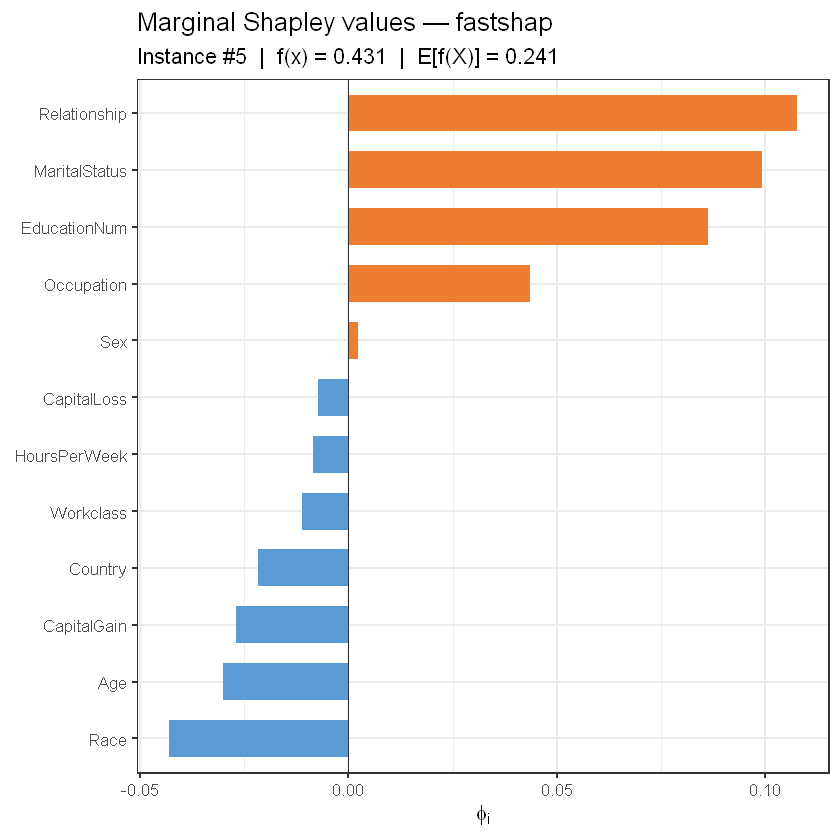

In [8]:
# ── Waterfall plot ───────────────
sv_df <- data.frame(
  feature = colnames(sv_local),
  phi     = as.numeric(sv_local)
) |>
  arrange(phi) |>
  mutate(
    feature   = factor(feature, levels = feature),
    direction = ifelse(phi >= 0, "positive", "negative")
  )

ggplot(sv_df, aes(x = phi, y = feature, fill = direction)) +
  geom_col(width = 0.65) +
  geom_vline(xintercept = 0, linewidth = 0.5, colour = "grey20") +
  scale_fill_manual(values = c(positive = "#ED7D31", negative = "#5A9BD5"),
                    guide = "none") +
  labs(
    title    = "Marginal Shapley values — fastshap",
    subtitle = sprintf("Instance #%d  |  f(x) = %.3f  |  E[f(X)] = %.3f",
                       INSTANCE_IDX, pred_int, E_f_X),
    x = expression(phi[i]),
    y = NULL
  ) +
  theme_bw(base_size = 13)

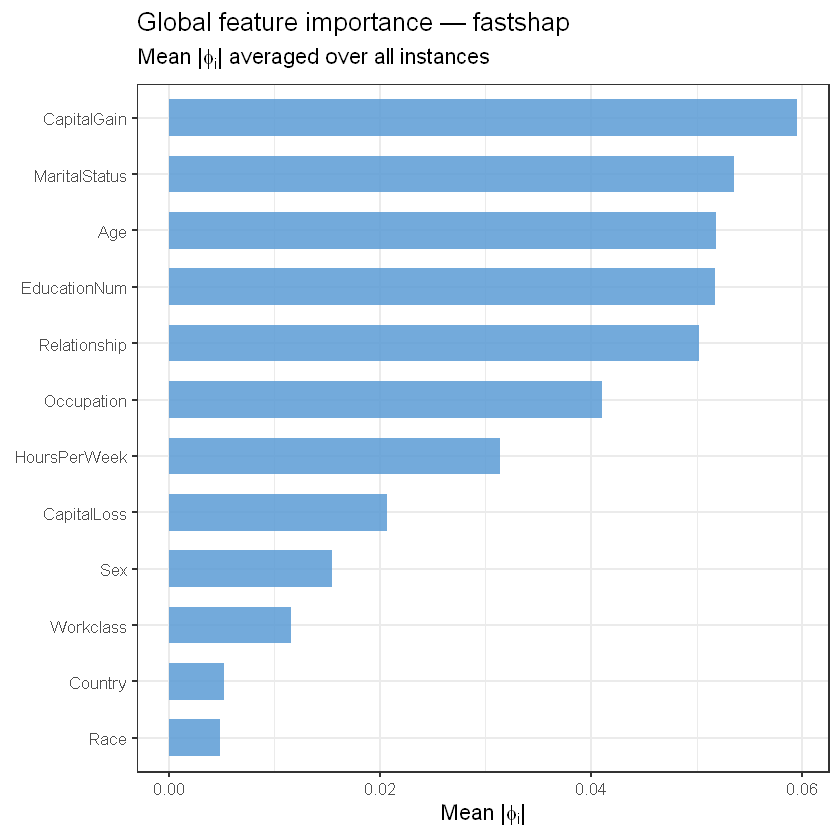

In [9]:
# ── Global Shapley values (on all the training data) ────────────────────────────
set.seed(42)
sv_global <- explain(
  object       = model,
  X            = X_enc,
  pred_wrapper = pfun,
  nsim         = 50,          # fewer simulations for speed
  adjust       = TRUE
)

# ── Mean |φᵢ| importance plot ────────────────────────────────────────────────
imp_df <- colMeans(abs(sv_global)) |>
  sort(decreasing = FALSE) |>
  tibble::enframe(name = "feature", value = "importance") |>
  mutate(feature = factor(feature, levels = feature))

ggplot(imp_df, aes(x = importance, y = feature)) +
  geom_col(fill = "#5A9BD5", alpha = 0.85, width = 0.65) +
  labs(
    title    = "Global feature importance — fastshap",
    subtitle = expression(paste("Mean |", phi[i], "| averaged over all instances")),
    x = expression(paste("Mean |", phi[i], "|")),
    y = NULL
  ) +
  theme_bw(base_size = 13)

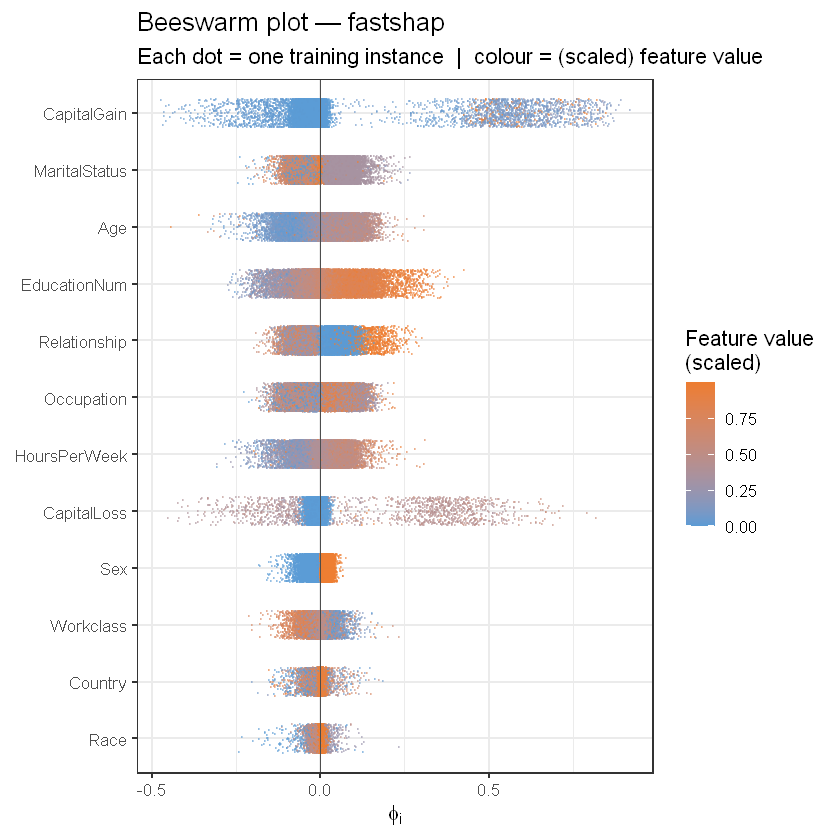

In [10]:
# ── Beeswarm plot ────────────────────────────────────────────────
sv_long <- as.data.frame(sv_global) |>
  tibble::rownames_to_column("obs") |>
  tidyr::pivot_longer(-obs, names_to = "feature", values_to = "shap") |>
  left_join(
    as.data.frame(X_enc) |>
      tibble::rownames_to_column("obs") |>
      tidyr::pivot_longer(-obs, names_to = "feature", values_to = "fval"),
    by = c("obs", "feature")
  ) |>
  group_by(feature) |>
  mutate(fval_scaled = (fval - min(fval)) / (max(fval) - min(fval) + 1e-8)) |>
  ungroup() |>
  mutate(feature = factor(feature, levels = levels(imp_df$feature)))

ggplot(sv_long, aes(x = shap, y = feature, colour = fval_scaled)) +
  geom_jitter(height = 0.25, size = 0.3, alpha = 0.4) +
  geom_vline(xintercept = 0, linewidth = 0.4, colour = "grey30") +
  scale_colour_gradient(low = "#5A9BD5", high = "#ED7D31",
                        name = "Feature value\n(scaled)") +
  labs(
    title = "Beeswarm plot — fastshap",
    subtitle = "Each dot = one training instance  |  colour = (scaled) feature value",
    x = expression(phi[i]),
    y = NULL
  ) +
  theme_bw(base_size = 13)

# Package `iml`

**[iml](https://github.com/christophM/iml)** (Molnar 2018) provides a unified interface for model-agnostic interpretability in R. It wraps any model behind a `Predictor` object and offers Shapley values, partial dependence, feature importance, and more.

The `Shapley` class computes the **marginal Shapley values**, as `fastshap`. It is conceptually equivalent to `shap.KernelExplainer` with the training data as background.

## Marginal Shapley values with the `iml` package

In [11]:
# ── Predictor object ──────────────────────────────────────────────────────────
predictor <- Predictor$new(
  model            = model,
  data             = X_enc,    # background data for sampling
  y                = y,
  predict.function = function(model, newdata) {
    predict(model, xgb.DMatrix(as.matrix(newdata)))
  }
)

# ── Local Shapley values (marginal) ───────────────────────────────────────────
shap_iml <- Shapley$new(
  predictor   = predictor,
  x.interest  = x_int,
  sample.size = 100     # Monte Carlo samples — same as fastshap nsim
)

cat("=== Shapley values (iml) ===\n")
print(shap_iml$results)

=== Shapley values (iml) ===
         feature          phi     phi.var   feature.value
1            Age -0.035556447 0.024783378          Age=28
2   EducationNum  0.075729578 0.017553097 EducationNum=13
3    CapitalGain -0.042163865 0.023687796   CapitalGain=0
4    CapitalLoss  0.000000000 0.000000000   CapitalLoss=0
5   HoursPerWeek  0.012427091 0.007863145 HoursPerWeek=40
6      Workclass -0.014952417 0.004535821     Workclass=5
7  MaritalStatus  0.098952144 0.020122725 MaritalStatus=3
8     Occupation  0.048115106 0.012851093   Occupation=11
9   Relationship  0.123252767 0.028112569  Relationship=6
10          Race -0.041054534 0.006448188          Race=3
11           Sex -0.012022062 0.002000840           Sex=1
12       Country  0.001237268 0.008142751       Country=6


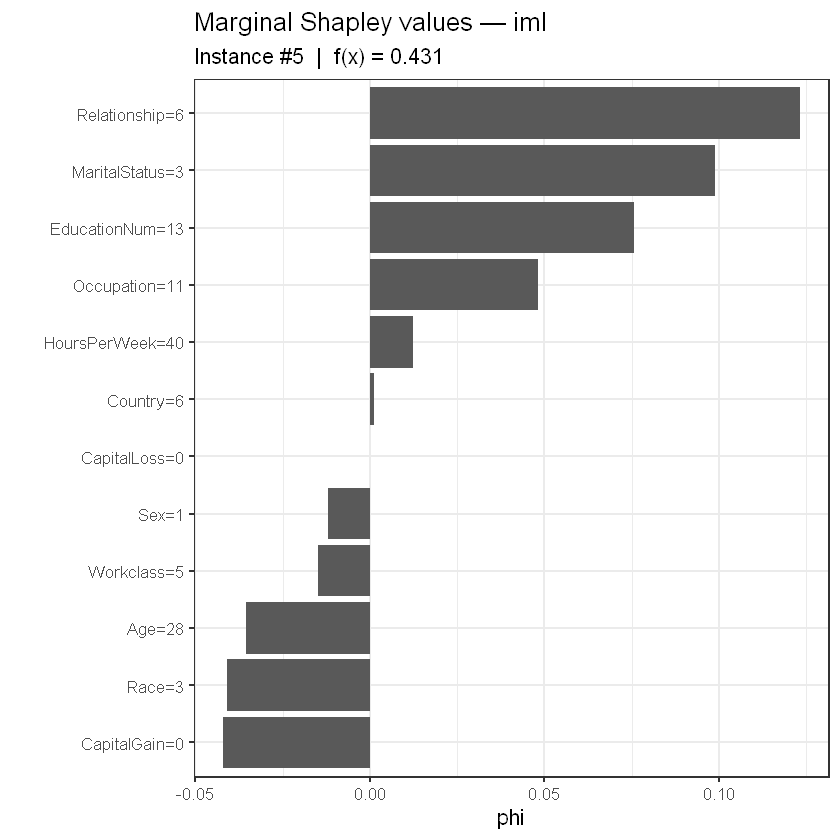

In [12]:
plot(shap_iml) +
  labs(
    title    = "Marginal Shapley values — iml",
    subtitle = sprintf("Instance #%d  |  f(x) = %.3f", INSTANCE_IDX, pred_int)
  ) +
  theme_bw(base_size = 13)

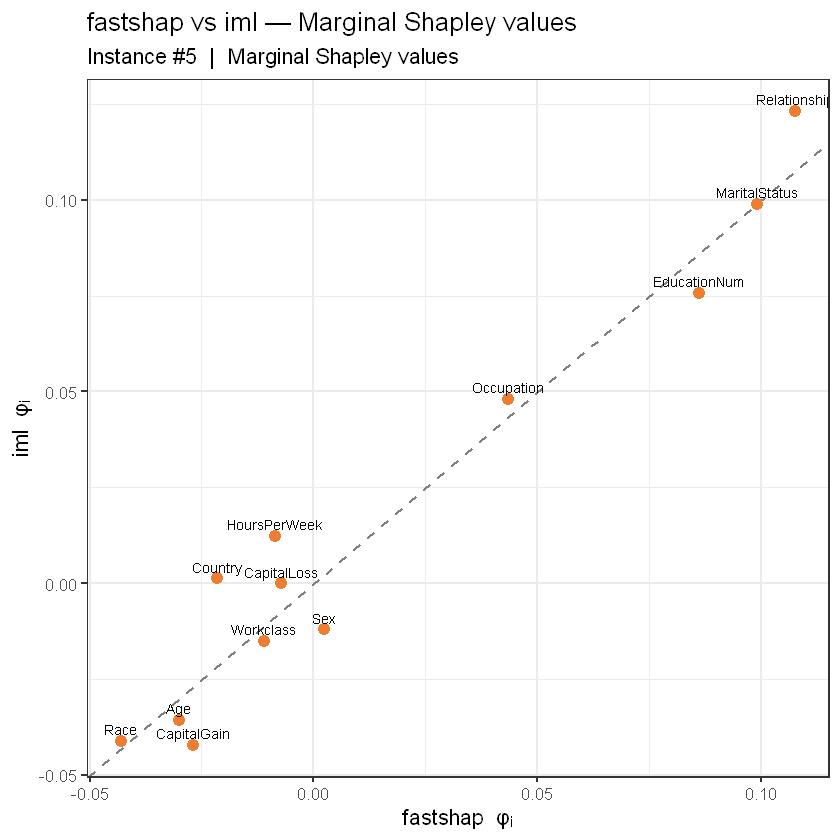

In [13]:
# ── fastshap vs iml: do both methods agree? ───────────────────────────────────
# Both compute the Marginal Shapley values → attributions should be similar (up to MC noise)

iml_phi <- setNames(shap_iml$results$phi, shap_iml$results$feature)
fst_phi <- setNames(as.numeric(sv_local), colnames(sv_local))

cmp2_df <- data.frame(
  feature  = names(fst_phi),
  fastshap = fst_phi,
  iml      = iml_phi[names(fst_phi)]   # align by name
)

ggplot(cmp2_df, aes(x = fastshap, y = iml)) +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed", colour = "grey50") +
  geom_point(colour = "#ED7D31", size = 3) +
  geom_text(aes(label = feature), size = 3, vjust = -0.6, hjust = 0.5) +
  labs(
    title    = "fastshap vs iml — Marginal Shapley values",
    subtitle = sprintf("Instance #%d  |  Marginal Shapley values", INSTANCE_IDX),
    x = "fastshap  φᵢ",
    y = "iml  φᵢ"
  ) +
  theme_bw(base_size = 13)

# Package `sensitivity`

The **[sensitivity](https://cran.r-project.org/package=sensitivity)** package implements methods for **global sensitivity analysis (GSA)**.

This package offers functions to perform **variance decomposition** (Shapley effects and Proportional Marginal Effects).

The conditional expectations are sampled using a nearest-neighbor scheme.

## Shapley effects with the `sensitivity` package

In [14]:
# ── Shapley effects ───────────────────────────────────
# Sub-sample for speed
set.seed(12345)
n_sample = 1000
X_se <- X_enc[sample(nrow(X_enc), n_sample),]

shapley_effects <- shapleysobol_knn(model=NULL, X=X_se, n.knn = 6, parl=detectCores()-1)
shapley_effects <- tell(shapley_effects, y=pred_all)
shapley_effects


Call:
compute.shapleysobol_knn(X = x$X, y = x$y, method = x$method,     n.knn = x$n.knn, n.limit = x$n.limit, U = x$U, n.perm = x$n.perm,     noise = x$noise, rescale = x$rescale, nboot = x$nboot, boot.level = x$boot.level,     conf = x$conf, parl = x$parl, boot = x$boot)

Shapley effects estimation by nearest-neighbor procedure
                 original
Age           0.128745011
EducationNum  0.069424787
CapitalGain   0.096826617
CapitalLoss   0.107364844
HoursPerWeek  0.118733229
Workclass     0.006984709
MaritalStatus 0.010833708
Occupation    0.141505333
Relationship  0.057722560
Race          0.159857793
Sex           0.005542710
Country       0.096458699

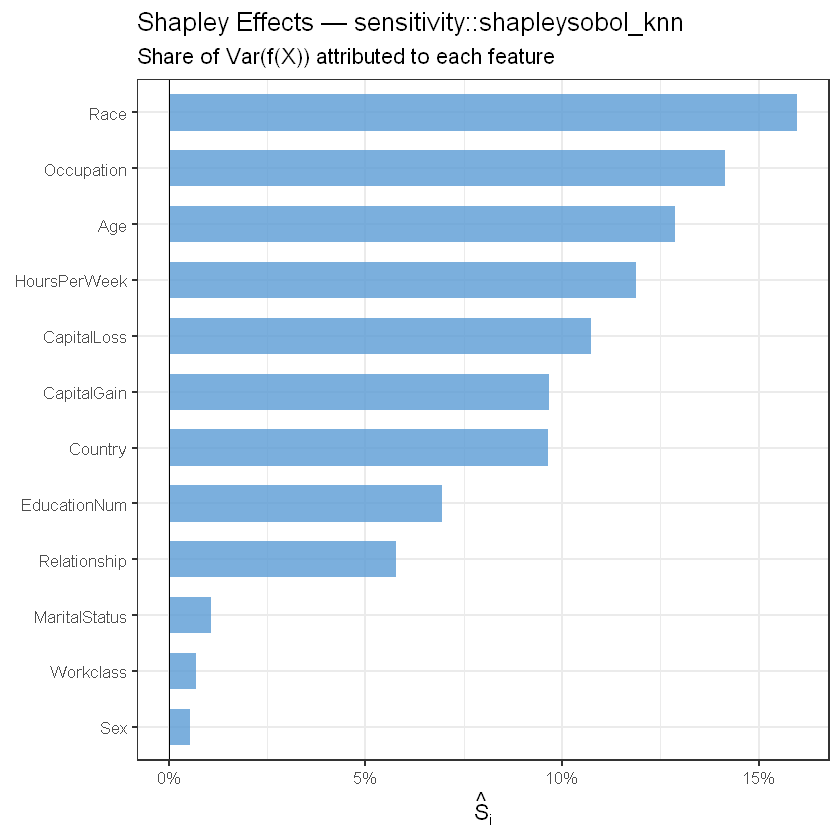

In [15]:
# Extract estimates from the output object
Shap_mat <- shapley_effects$Shap   # matrix: rows = variables, columns = replications

shap_eff_df <- data.frame(
  feature = colnames(X_enc),
  S_mean  = rowMeans(Shap_mat),
  S_sd    = apply(Shap_mat, 1, sd)
) |>
  mutate(
    S_lo  = S_mean - 1.96 * S_sd / sqrt(ncol(Shap_mat)),
    S_hi  = S_mean + 1.96 * S_sd / sqrt(ncol(Shap_mat))
  ) |>
  arrange(S_mean) |>
  mutate(feature = factor(feature, levels = feature))

ggplot(shap_eff_df, aes(x = S_mean, y = feature)) +
  geom_col(fill = "#5A9BD5", alpha = 0.80, width = 0.65) +
  geom_errorbar(aes(xmin = S_lo, xmax = S_hi), width = 0.3, colour = "grey30") +
  geom_vline(xintercept = 0, linewidth = 0.4) +
  scale_x_continuous(labels = scales::percent_format()) +
  labs(
    title    = "Shapley Effects — sensitivity::shapleysobol_knn",
    subtitle = "Share of Var(f(X)) attributed to each feature",
    x        = expression(hat(S)[i]),
    y        = NULL
  ) +
  theme_bw(base_size = 13)

## Proportional Marginal Effects with the `sensitivity` package

In [16]:
# ── Proportional Marginal Effects ───────────────────────────────────
# Sub-sample for speed
set.seed(12345)

pme <- pme_knn(model=NULL, X=X_se, n.knn = 6, parl=detectCores()-1)
pme <- tell(pme, y=pred_all)
pme


Call:
compute.pme_knn(X = x$X, y = x$y, method = x$method, tol = x$tol,     marg = x$marg, n.knn = x$n.knn, n.limit = x$n.limit, noise = x$noise,     rescale = x$rescale, nboot = x$nboot, boot.level = x$boot.level,     conf = x$conf, parl = x$parl, boot = x$boot)

Proportional marginal effects estimation by nearest-neighbor procedure
                original
Age           0.08505876
EducationNum  0.05369546
CapitalGain   0.09193648
CapitalLoss   0.09542700
HoursPerWeek  0.07307494
Workclass     0.03585805
MaritalStatus 0.03666373
Occupation    0.09119900
Relationship  0.05142000
Race          0.26119064
Sex           0.03510143
Country       0.08937451

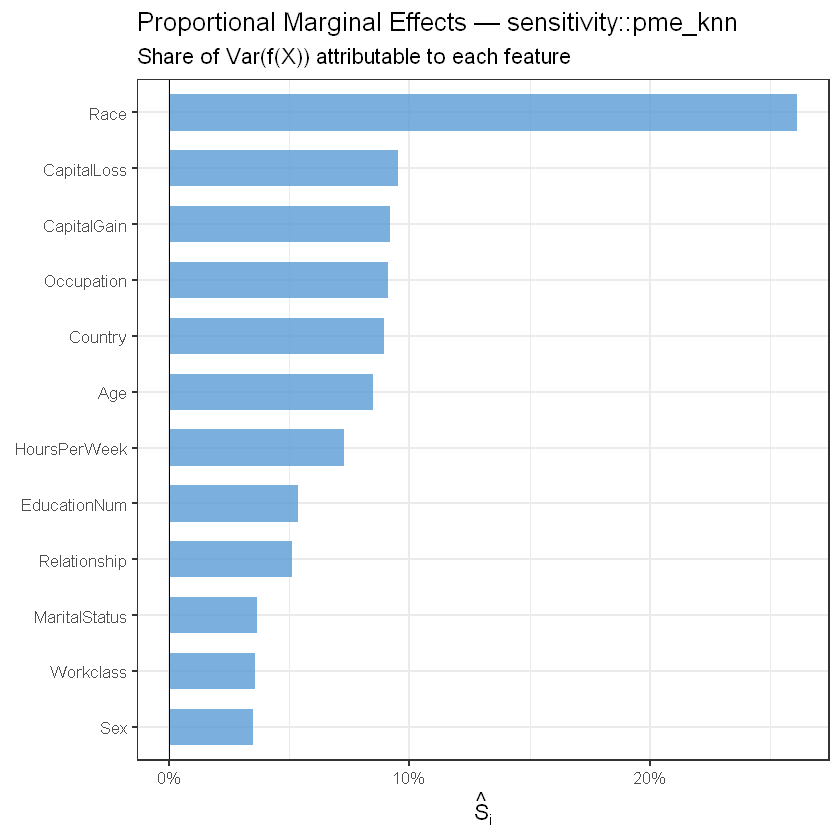

In [17]:
# Extract estimates from the output object
pme_mat <- pme$PME   # matrix: rows = variables, columns = replications

pme_df <- data.frame(
  feature = colnames(X_enc),
  S_mean  = rowMeans(pme_mat),
  S_sd    = apply(pme_mat, 1, sd)
) |>
  mutate(
    S_lo  = S_mean - 1.96 * S_sd / sqrt(ncol(Shap_mat)),
    S_hi  = S_mean + 1.96 * S_sd / sqrt(ncol(Shap_mat))
  ) |>
  arrange(S_mean) |>
  mutate(feature = factor(feature, levels = feature))

ggplot(pme_df, aes(x = S_mean, y = feature)) +
  geom_col(fill = "#5A9BD5", alpha = 0.80, width = 0.65) +
  geom_errorbar(aes(xmin = S_lo, xmax = S_hi), width = 0.3, colour = "grey30") +
  geom_vline(xintercept = 0, linewidth = 0.4) +
  scale_x_continuous(labels = scales::percent_format()) +
  labs(
    title    = "Proportional Marginal Effects — sensitivity::pme_knn",
    subtitle = "Share of Var(f(X)) attributable to each feature",
    x        = expression(hat(S)[i]),
    y        = NULL
  ) +
  theme_bw(base_size = 13)

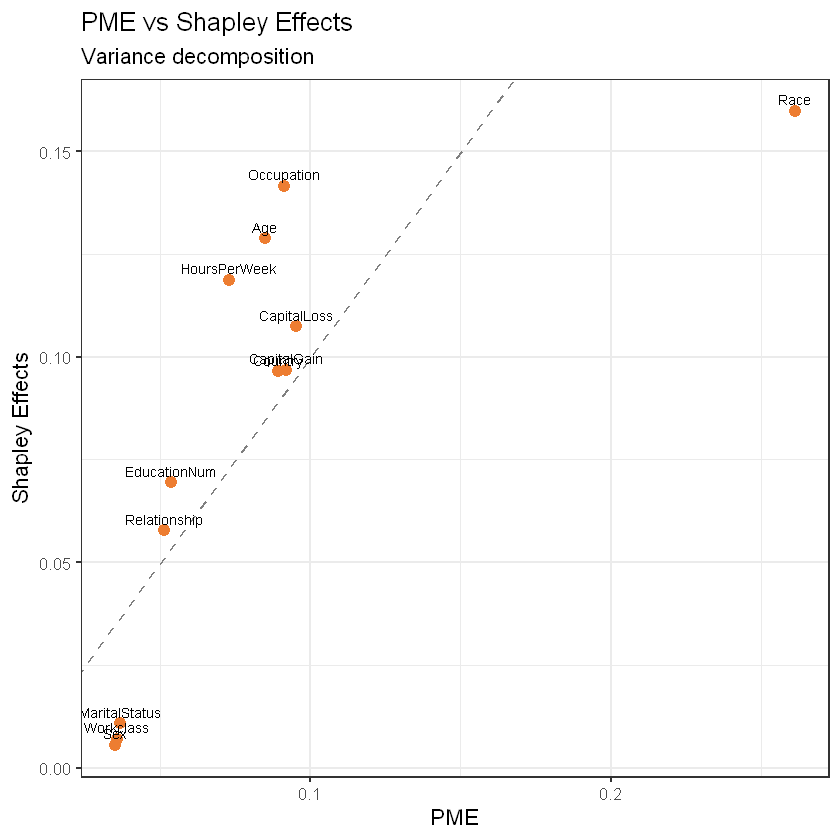

In [18]:
# ── Shapley Effects vs PME: do both methods agree? ───────────────────────────────────
cmp2_df <- data.frame(
  feature         = rownames(Shap_mat),          # rownames, pas names()
  pme             = rowMeans(pme_mat),            # réduire matrice → vecteur
  shapley_effects = rowMeans(Shap_mat)            # idem
)

ggplot(cmp2_df, aes(x = pme, y = shapley_effects)) +   # colonnes du df, pas les objets globaux
  geom_abline(slope = 1, intercept = 0, linetype = "dashed", colour = "grey50") +
  geom_point(colour = "#ED7D31", size = 3) +
  geom_text(aes(label = feature), size = 3, vjust = -0.6, hjust = 0.5) +
  labs(
    title    = "PME vs Shapley Effects",
    subtitle = "Variance decomposition",
    x        = "PME",
    y        = "Shapley Effects"
  ) +
  theme_bw(base_size = 13)